# Chapter 05 — Chunking & Contextual Enrichment

*Where we are:* normalized documents become the **units we retrieve and cite**.

```
normalized docs →[ chunking + enrichment ]→ BM25 / dense indexes → retrieval
```

## 17. Chunking is not merely about token limits

Chunking decides **semantic coherence**, **retrieval granularity**, **answerability** and —
uniquely for patents — **citation boundaries**. A chunk is both what you *retrieve* and what you
*cite*, so its boundaries must respect structure (sections, claims) and it must carry provenance.

> In a patent system, chunking is partly an IR problem and partly a **citability problem**.

In [1]:
# === Chapter 05 · standard bootstrap (identical pattern in every notebook) ===
# Runs standalone on a fresh Google Colab VM *or* a local checkout.
import os, sys, subprocess

REPO_URL = "https://github.com/rsalehin/patent-rag-masterclass"
NEED_OCR = False
IN_COLAB = "google.colab" in sys.modules


def _clone_repo(url, target):
    """Clone the repo on Colab. For a PRIVATE repo, authenticate with a GitHub token read from
    Colab Secrets (key 'GITHUB_TOKEN') or the GITHUB_TOKEN env var. The token is never printed."""
    token = None
    try:
        from google.colab import userdata  # type: ignore
        token = userdata.get("GITHUB_TOKEN")
    except Exception:
        token = os.environ.get("GITHUB_TOKEN")
    auth_url = url
    if token and url.startswith("https://github.com/"):
        auth_url = url.replace("https://github.com/", f"https://{token}@github.com/")
    r = subprocess.run(["git", "clone", "--depth", "1", auth_url, target],
                       stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)  # avoid leaking the token
    if r.returncode != 0:
        raise RuntimeError(
            "git clone failed. This is a PRIVATE repo, so Colab needs a GitHub token:\n"
            "  1) Create a token (scope: repo) at https://github.com/settings/tokens\n"
            "  2) In Colab, open the key icon (Secrets) in the left sidebar, add a secret named\n"
            "     GITHUB_TOKEN, paste the token, and enable 'Notebook access'.\n"
            "  3) Re-run this cell.\n"
            "  (Alternatively, make the GitHub repo public — then no token is needed.)")


if IN_COLAB:
    target = "/content/patent-rag-masterclass"
    if not os.path.isdir(target):
        if not REPO_URL:
            raise RuntimeError("Set REPO_URL to this repo's GitHub URL (see README.md).")
        _clone_repo(REPO_URL, target)
    os.chdir(target)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
    if NEED_OCR:
        subprocess.run(["apt-get", "install", "-y", "-q", "tesseract-ocr"], check=False)

# Ensure the repo root (containing patentrag/) is importable.
for _cand in [os.getcwd()] + [os.path.dirname(os.getcwd())]:
    if os.path.isdir(os.path.join(_cand, "patentrag")):
        if _cand not in sys.path:
            sys.path.insert(0, _cand)
        break

from patentrag import bootstrap as bs
bs.setup_environment(REPO_URL, need_ocr=NEED_OCR)
bs.set_seeds()
_env = bs.environment_report()
print("Chapter 05 bootstrap OK")
print("  Python", _env["python"], "| Colab:", _env["in_colab"], "| CPU cores:", _env["cpu_count"])
print("  torch", _env["torch"], "| CUDA:", _env["cuda_available"], "| tesseract:", _env["tesseract"])

Chapter 05 bootstrap OK
  Python 3.12.10 | Colab: False | CPU cores: 24
  torch 2.12.0.dev20260304+cu130 | CUDA: True | tesseract: True


## 18. Strategies compared

We compare, on one real section: **fixed** token windows, **overlapping** windows, **paragraph**
chunks, and structure-aware chunking. Naive strategies cut mid-sentence or merge unrelated
paragraphs; structure-aware chunking respects section and claim boundaries.

In [2]:
import pandas as pd
from patentrag.chunking import fixed_token_chunks, paragraph_chunks, chunk_document, estimate_tokens
docs = bs.ensure("docs_canonical")
d = next(x for x in docs if x.doc_id == "US10261954B2")
section = next(s for s in d.sections if s.kind.value == "background")
text = section.text
print(f"section '{section.heading}' — {estimate_tokens(text)} tokens\n")
comp = pd.DataFrame([
    {"strategy": "fixed (180, no overlap)", "n_chunks": len(fixed_token_chunks(text, 180, 0))},
    {"strategy": "fixed (180, overlap 30)", "n_chunks": len(fixed_token_chunks(text, 180, 30))},
    {"strategy": "paragraph",               "n_chunks": len(paragraph_chunks(text))},
])
comp

section 'BACKGROUND' — 1032 tokens



,strategy,n_chunks
0,"fixed (180, no overlap)",6
1,"fixed (180, overlap 30)",7
2,paragraph,10


In [3]:
# Fixed windows cut mid-sentence; paragraph/section-aware respect meaning boundaries.
fx = fixed_token_chunks(text, 40, 0)
print("fixed-40 chunk boundary (note the mid-sentence cut):")
print("  ...", fx[0][-60:], "|CUT|", fx[1][:60], "...")

fixed-40 chunk boundary (note the mid-sentence cut):
  ... herwise indicated , it should not be assumed that any of the |CUT| approaches described in this section qualify as prior art me ...


### The patent structure we chunk around

```
Patent
 ├── Abstract
 ├── Description
 │    ├── Background
 │    ├── Summary
 │    └── Detailed Description
 └── Claims
      ├── Claim 1 (independent)
      ├── Claim 2 (dependent)
      └── ...
```

`chunk_document` produces **section-aware** description chunks (packed to ~180 tokens on
paragraph boundaries, with 1-paragraph overlap) plus **one chunk per claim** (claims are atomic
citation units). Every chunk keeps its `SourceAnchor` (offsets → OffsetMap → original).

In [4]:
chunks = chunk_document(d)
claim_chunks = [c for c in chunks if c.claim_number is not None]
sec_chunks = [c for c in chunks if c.claim_number is None]
print(f"{d.doc_id}: {len(chunks)} chunks = {len(sec_chunks)} section + {len(claim_chunks)} claim")
c = sec_chunks[3]
print("\nexample section chunk:")
print("  id:", c.chunk_id, "| section:", c.section, "| kind:", c.section_kind.value, "| tokens:", c.token_estimate)
print("  anchor: norm[%d:%d] -> orig[%d:%d]" % (c.anchor.norm_start, c.anchor.norm_end, c.anchor.orig_start, c.anchor.orig_end))
print("  text:", c.text[:120], "...")

US10261954B2: 69 chunks = 50 section + 19 claim

example section chunk:
  id: df747d82b830 | section: BACKGROUND | kind: background | tokens: 143
  anchor: norm[0:845] -> orig[0:845]
  text: The approaches described in this section are approaches that could be pursued, but not necessarily approaches that have  ...


In [5]:
# Provenance is preserved: recover the exact original substring this chunk came from.
from patentrag.normalize import normalize_document
nd = normalize_document(d)
ns = nd.section(c.anchor.section_id)
recovered = ns.offset_map.recover_original(c.anchor.norm_start, c.anchor.norm_end)
print("recovered == original slice:", recovered == ns.original[c.anchor.orig_start:c.anchor.orig_end])
print("recovered (head):", repr(recovered[:80]))

recovered == original slice: True
recovered (head): 'The approaches described in this section are approaches that could be pursued, b'


## 19. Contextual enrichment

A dependent claim chunk like *"The method of claim 1, wherein the second component…"* is nearly
meaningless alone — and nearly **unretrievable** by a topical query. Enrichment prepends compact
disambiguating context (title, section/claim, CPC) **without** dumping the whole patent.

In [6]:
cc = claim_chunks[1]   # a dependent claim
print("RAW chunk text:\n ", cc.text[:110], "...\n")
print("ENRICHED (what we actually index/embed):\n ", cc.enriched_text.split(chr(10))[0])
print(" ", cc.enriched_text.split(chr(10))[1][:110], "...")

RAW chunk text:
  The method of claim 1 , further comprising: based at least in part on the user click and the user dwell time,  ...

ENRICHED (what we actually index/embed):
  Patent US10261954B2: Optimizing search result snippet selection | Claim 2 (dependent claim) | CPC: G06F
  The method of claim 1 , further comprising: based at least in part on the user click and the user dwell time,  ...


### Before/after enrichment — a measured retrieval comparison

We build two BM25 indexes over the corpus chunks — one on **raw** text, one on **enriched** text
— and issue a topical query. Enrichment lets a dependent claim surface for a query that uses the
patent's *topic* words (which appear in the title/section header, not the claim body).

In [7]:
from patentrag.sparse import BM25Retriever
all_chunks = bs.ensure("chunks")   # enriched corpus chunks (the production artifact)
ids = [c.chunk_id for c in all_chunks]
raw_idx = BM25Retriever().fit(ids, [c.text for c in all_chunks])
enr_idx = BM25Retriever().fit(ids, [c.for_index() for c in all_chunks])

doc_of = {c.chunk_id: c.document_id for c in all_chunks}
query = "personalized recommendation deep embedding architecture"   # topic words in title/section
target_doc = "US11113744B2"

def count_in_topk(retriever, k=15):
    return sum(1 for cid, _ in retriever.search(query, k) if doc_of[cid] == target_doc)

def rank_of(retriever, cid):
    for rank, (c, _) in enumerate(retriever.search(query, 300), 1):
        if c == cid:
            return rank
    return None

# a dependent claim whose body does NOT contain the topic words is the hardest case
dep = [c for c in all_chunks if c.document_id == target_doc and c.claim_number and c.claim_number > 1]
hard = dep[3]
print(f"query: {query!r}   target patent: {target_doc}\n")
print(f"  # of target's chunks in top-15   — RAW: {count_in_topk(raw_idx)}   ENRICHED: {count_in_topk(enr_idx)}")
print(f"  rank of dependent claim {hard.claim_number} (body lacks topic words):")
print(f"      RAW: {rank_of(raw_idx, hard.chunk_id)}   ENRICHED: {rank_of(enr_idx, hard.chunk_id)}")
print(f"      claim body: {hard.text[:70]}...")

query: 'personalized recommendation deep embedding architecture'   target patent: US11113744B2

  # of target's chunks in top-15   — RAW: 9   ENRICHED: 12
  rank of dependent claim 5 (body lacks topic words):
      RAW: 55   ENRICHED: 38
      claim body: The system of claim 1 , wherein building the list of personalized reco...


## Chunk-size distribution (corpus-wide)

Well-formed chunks cluster around the target size, with a tail of long *atomic claims* (we never
split a claim — it is a citation unit).

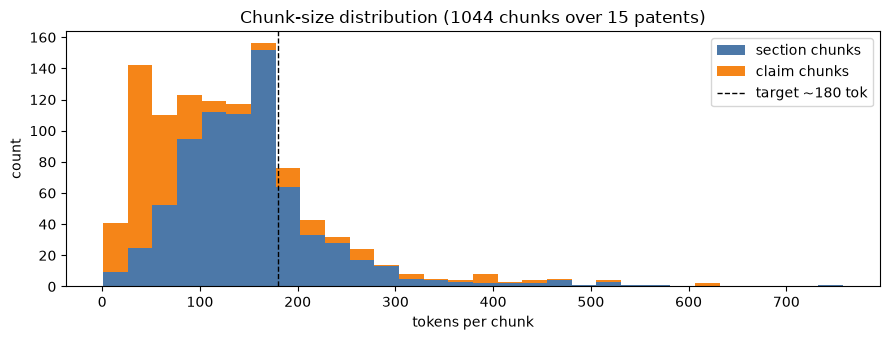

chunks: 1044 | median 125 tok | mean 136 | max 758 (a long claim)


In [8]:
import matplotlib.pyplot as plt, numpy as np
sizes = np.array([c.token_estimate for c in all_chunks])
claim_sizes = np.array([c.token_estimate for c in all_chunks if c.claim_number is not None])
sec_sizes = np.array([c.token_estimate for c in all_chunks if c.claim_number is None])
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.hist([sec_sizes, claim_sizes], bins=30, stacked=True, label=["section chunks", "claim chunks"],
        color=["#4C78A8", "#F58518"])
ax.axvline(180, color="k", ls="--", lw=1, label="target ~180 tok")
ax.set_xlabel("tokens per chunk"); ax.set_ylabel("count"); ax.legend()
ax.set_title(f"Chunk-size distribution ({len(all_chunks)} chunks over {len(docs)} patents)")
plt.tight_layout(); plt.show()
print(f"chunks: {len(all_chunks)} | median {int(np.median(sizes))} tok | mean {sizes.mean():.0f} | max {sizes.max()} (a long claim)")

**Production implications.** Structure-aware chunking improves both retrieval *and* citation
quality; enrichment trades a little index size for large recall gains on fragmentary chunks. The
cost is bookkeeping — every chunk must carry its anchor so the enrichment text is never confused
with the citable original.

## Chapter invariants

In [9]:
# Structure preserved, provenance intact, enrichment separate from citable text.
assert any(c.claim_number is not None for c in all_chunks) and any(c.claim_number is None for c in all_chunks)
assert all(c.token_estimate > 0 for c in all_chunks)
assert cc.enriched_text and cc.enriched_text != cc.text and cc.text in cc.enriched_text
# every section chunk's anchor recovers its exact original text
sc = next(c for c in chunks if c.claim_number is None)
ns = nd.section(sc.anchor.section_id)
assert ns.offset_map.recover_original(sc.anchor.norm_start, sc.anchor.norm_end) == \
       ns.original[sc.anchor.orig_start:sc.anchor.orig_end]
print("All Chapter 05 invariants hold. chunks artifact ready.")

All Chapter 05 invariants hold. chunks artifact ready.


In [10]:
# === Chapter 05 validation footer ===
import time, platform, sys, importlib.metadata as _md
_pkgs = ['rank-bm25', 'matplotlib', 'numpy']
print("Chapter 05 — environment")
print("  Python :", sys.version.split()[0], "on", platform.system(), platform.release())
for _p in _pkgs:
    try: print(f"  {_p:24}: {_md.version(_p)}")
    except Exception: print(f"  {_p:24}: (not installed)")
print()
print("CHAPTER 05 VALIDATION: PASS")

Chapter 05 — environment
  Python : 3.12.10 on Windows 11
  rank-bm25               : 0.2.2
  matplotlib              : 3.11.1
  numpy                   : 2.4.2

CHAPTER 05 VALIDATION: PASS
